# Neural Network Training Tips & Tricks

More information on configuring neural network training can be found, for example, in:
* [A Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/) by Andrej Karpathy.
* [Bag of Tricks for Image Classification with Convolutional Neural Networks](https://arxiv.org/abs/1812.01187) - a 2018 paper on training convolutional neural networks
* [Tips for Model Training](https://docs.ultralytics.com/guides/model-training-tips/#community-resources) by the well-known `ultralytics` team and other guides from them and other teams.
* and in other relevant publications by well-known practitioners, for example [here](https://sebastianraschka.com/blog/2023/pytorch-faster.html), [here](https://github.com/vahidk/EffectivePyTorch), [here](https://github.com/rasbt/deeplearning-models), as well as official `PyTorch` publications, [for example](https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html), and well-known example collections, [for example](https://madewithml.com/) or [here](https://github.com/Conchylicultor/Deep-Learning-Tricks).
<!-- и [тут](https://stackoverflow.com/questions/70554413/how-to-improve-the-performance-of-cnn-model-for-a-specific-dataset-getting-low). -->
* It is also important to keep in mind issues of acceleration and computational optimization of neural network training, see, [for example](https://habr.com/ru/companies/wunderfund/articles/820721/).
* It is also important to keep in mind hyperparameter tuning for neural network training, see, [for example](https://pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html) and [here](https://docs.ray.io/en/latest/tune/getting-started.html) and [here](https://docs.ray.io/en/latest/tune/examples/tune-pytorch-cifar.html).
* A course with many examples [here](https://deeplearning.neuromatch.io/tutorials/W1D5_Optimization/chapter_title.html).
* Guide [Deep Learning Tuning Playbook](https://github.com/google-research/tuning_playbook)
* [Some notes](https://habr.com/ru/companies/magnus-tech/articles/846012/)
<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1k5ih-FSbCTuErwBHHi3J3uCN1q4fRzFI) -->

Library recipes:
* [`skorch`](https://github.com/skorch-dev/skorch)
* [`bitsandbytes`](https://huggingface.co/docs/bitsandbytes/)

## Imports

In [1]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchmetrics import Accuracy, Precision, Recall, F1Score
import pandas as pd

In [2]:
import os
import urllib
if not os.path.exists('torch_trainer.py' ):
    url = "https://github.com/MVRonkin//Computer-Vision-Course_lec-practice/raw/refs/heads/main/2025//WS/torch_trainer.py"
    filename, headers = urllib.request.urlretrieve(url,filename='torch_trainer.py' )
if not os.path.exists('torch_find_hparam.py' ):
    url = "https://github.com/MVRonkin//Computer-Vision-Course_lec-practice/raw/refs/heads/main/2025//WS/torch_find_hparam.py"
    filename, headers = urllib.request.urlretrieve(url,filename='torch_find_hparam.py' )    

In [3]:
from torch_trainer import *
from torch_find_hparam import *

Let's configure the `PyTorch` environment using the `setup_experiment` function. We will select the execution format and the compute device.

Sets up the environment for reproducible experiments in PyTorch.

-  `seed (int)`: Seed for random number generators `(Python, NumPy, PyTorch)`.
-  `deterministic (bool)`: Enable deterministic behavior for `CuDNN` operations (may reduce speed).
-  `benchmark (bool)`: Enable CuDNN benchmark for automatic selection of fast algorithms (incompatible with `deterministic=True`).
-  `allow_tf32 (bool)`: Allow TensorFloat32 usage on Ampere+ GPUs (speeds up computations with a slight loss of precision).
-  `device_preference (str)`: `"cpu"`, `"cuda"`, `"mps"`, or `"auto"` — device selection.

Returns the device on which computations will be performed.

In [4]:
device = setup_experiment(seed=42, device_preference="auto")

[✓] Device: cuda | Seed: 42 | TF32: True


# Overview of the `timm` Library

In [5]:
import timm

The [timm (PyTorch Image Models)](https://huggingface.co/timm) library is one of the most popular tools for computer vision image classification tasks, as well as for building powerful `feature extractors` for more complex architectures. The [`timm` library](https://github.com/huggingface/pytorch-image-models) supports more than 1000 pretrained models and has tight integration with the `Hugging Face` ecosystem.

<!-- [Библиотека `timm`](https://huggingface.co/docs/timm/index) предоставляет встроенная поддержка `transfer learnin`: — например, замену головной части классификатора под нужное число классов или указание количество входных каналов (обычно 3 для `RGB`-изображений или 1 для `grayscale`). Это особенно удобно при работе с нестандартными доменами — от медицинских снимков до спутниковых изображений.

Помимо моделей, [библиотека `timm`](https://github.com/huggingface/pytorch-image-models) предоставляет готовые и согласованные пайплайны обработки данных, включая автоматическую настройку аугментаций и нормализации под конкретную архитектуру через `timm.data.create_transform()` и `resolve_data_config()`. Это гарантирует, что входные данные будут обработаны так же, как и при оригинальном предобучении — критически важное условие для стабильной и точной инференции.

[Библиотека `timm`](https://huggingface.co/docs/timm/index) полностью совместим с `Hugging Face Hub`: модели можно не только загружать напрямую из репозиториев `Hugging Face`, но и публиковать собственные веса, делая их доступными для сообщества. Такая интеграция упрощает воспроизводимость экспериментов и совместную работу. -->

Models in `Timm` can be found using the [Hugging Face model search](https://huggingface.co/models?pipeline_tag=image-classification&library=timm,pytorch&sort=trending) or the `list_models` function as shown below.

In [6]:
model_names = timm.list_models('mobilev*')
print(model_names[:15])

['mobilevit_s', 'mobilevit_xs', 'mobilevit_xxs', 'mobilevitv2_050', 'mobilevitv2_075', 'mobilevitv2_100', 'mobilevitv2_125', 'mobilevitv2_150', 'mobilevitv2_175', 'mobilevitv2_200']


In this lesson we will look at working with `TIMM` using the `mobilenetv3_small` architecture as an example. This architecture is a modification of the `mobilenet v3` architecture.

<!-- В коде ниже

* `timm.create_model` — функция из библиотеки `timm` для загрузки архитектур нейронных сетей.

* `mobilenetv3_small_050` — название архитектуры конкрейтной: `mobilenet v3`.

* `pretrained=True` — загрузка весов, предварительно обученных на `ImageNet`.

* `num_classes=2` — количество классов на выходном слое (модель перестраивается под задачу бинарной классификации).

* `in_chans=3` — число входных каналов (3 соответствует `RGB`‑изображениям). -->

In [7]:
model = timm.create_model('mobilevitv2_050', pretrained=True, num_classes=2, in_chans=3)

<blockquote>

Note that if you have a local pretrained model, you can load it as a checkpoint:

```python
    model = timm.create_model(
    'resnet18',
    pretrained=False,
    checkpoint_path='/path/to/resnet18.pth'  # path to local .pth
)
```

</blockquote>

In [8]:
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,114,107


In [9]:
model.eval() 
with torch.inference_mode():
    out = model(torch.randn(7, 3, 224, 224))
    
print(f'Logits shape: {out.shape}')  

Logits shape: torch.Size([7, 2])


For such a model, for example, you can call the `feature_extractor` (`backbone`) separately.

Parameters:
* `num_classes=0` — removes the classifier,
* `global_pool=''` — disables global pooling.

In [10]:
backbone = timm.create_model('mobilenetv3_small_050', 
                             pretrained=True, 
                             num_classes=0, 
                             global_pool='')  # no head
features = backbone(torch.randn(7, 3, 224, 224))  
print(f"Feature map shape: {features.shape}")

Feature map shape: torch.Size([7, 1024, 7, 7])


Similarly, for a model with a specified head, you can get the head using the `get_classifier` method and replace it using the `reset_classifier` method.

In [11]:
model = timm.create_model('mobilenetv3_small_050', pretrained=True)

In [12]:
model.get_classifier()

Linear(in_features=1024, out_features=1000, bias=True)

In [13]:
model.reset_classifier(num_classes=2)
print(model.get_classifier())  # → Linear(in_features=512, out_features=2, bias=True)

Linear(in_features=1024, out_features=2, bias=True)


To freeze the `backbone`, you can use the methods shown below.

In [14]:
for param in model.parameters():
    param.requires_grad = False
model.get_classifier().requires_grad_(True)

Linear(in_features=1024, out_features=2, bias=True)

Similarly, you can replace the head with a custom one.

In [15]:
custom_head = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 2)  # 2 classes
)

In [16]:
model.classifier = custom_head  

<!-- Analogously, new transformations can be created using `create_transform`

Important notes:
1. `create_transform` expects `PIL.Image` as input, not `ndarray` or `torch.tensor`.
2. Therefore, if you open the dataset manually, always do:
`Image.open(path).convert("RGB")`
3. Do not apply `ToTensor()` manually!
`create_transform` already includes `ToTensor()` and `Normalize()` — do not add them twice!
4. For validation — only deterministic transformations. No random augmentations (unless you are doing `test time augmentation`)!
`is_training=False` → only `Resize, CenterCrop, ToTensor, Normalize`. -->

# Configuring the Training Process

## Dataset

In [17]:
from torchinfo import summary
from torchvision import transforms, datasets
from torchvision.datasets.utils import download_and_extract_archive

In [18]:
url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
root_directory = os.path.join(os.getcwd(),'data')

archive_name = url.split('/')[-1]
dataset_directory = os.path.join(root_directory, archive_name)
dataset_directory = os.path.splitext(dataset_directory)[0]

download_and_extract_archive(url, root_directory)

In [19]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
BATCH_SIZE  = 16

transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN,STD)
    ])

traindata = datasets.ImageFolder(os.path.join(dataset_directory, 'train'),transform)
valdata   = datasets.ImageFolder(os.path.join(dataset_directory, 'val'), transform)

trainloader = torch.utils.data.DataLoader(traindata, batch_size=BATCH_SIZE, shuffle=True)
valloader   = torch.utils.data.DataLoader(valdata, batch_size=BATCH_SIZE, shuffle=False, )

num_classes = len(traindata.classes)

## Optimizer

The most [common and popular](https://docs.pytorch.org/docs/stable/optim.html) optimizers can be found below.

> Also note the option to use more advanced and modern optimizers from [HuggingFace bitsandbytes](https://huggingface.co/docs/bitsandbytes/main/en/reference/optim/optim_overview) or the [torch_optimizer](https://github.com/jettify/pytorch-optimizer) or [timm](https://huggingface.co/docs/timm/en/reference/optimizers) libraries.
>
> Also note the existence of [algorithms for finding the optimal Learning Rate](https://github.com/davidtvs/pytorch-lr-finder). However, the well-known implementation is outdated and unmaintained. There is also an implementation in `pytorch_lightning`.
>
> Also, [`LR` depends on `BatchSize`](https://stackoverflow.com/questions/53033556/how-should-the-learning-rate-change-as-the-batch-size-change). The larger the batch, the larger the `LR`.

| Optimizer                                | Pros                                                                  | Cons                                                                    | When to use                                                                         |
|------------------------------------------|------------------------------------------------------------------------|-------------------------------------------------------------------------|-------------------------------------------------------------------------------------| 
| **SGD + momentum** / **SGD + Nesterov**  | - Simple and reliable<br>- Generalizes well<br>- Often gives best results with careful tuning | - Requires careful learning rate selection<br>- Slow convergence   | - Standard architectures (ResNet, VGG)<br>- When generalization is important<br>- When a good LR scheduler is available |
| **Adam / AdamW / NAdam / Adamax**        | - Adaptive learning rates<br>- Fast convergence<br>- Not very sensitive to initial LR | - Worse generalization compared to SGD<br>- Can get stuck in poor minima | - Quick prototyping / experiments<br>- Small datasets<br>- When generalization is not critical |
| **RMSprop**                              | - Good for recurrent networks and some CV tasks (e.g., older EfficientNet) | - Rarely used in modern CV models                          | - Legacy code<br>- Some mobile architectures                                   |

See more optimizers in [pytorch_optimizer](https://github.com/kozistr/pytorch_optimizer).

You can also use optimizers from timm — for this, use the `timm.optim.create_optimizer_v2` function.

```python
optimizer_name = 'adamw'          # supports: 'sgd', 'adam', 'adamw', 'rmsprop', etc.
learning_rate = 3e-4
weight_decay = 1e-2

# Create optimizer using create_optimizer_v2
optimizer = timm.optim.create_optimizer_v2(
    model,
    opt=optimizer_name,
    lr=learning_rate,
    weight_decay=weight_decay,
    # momentum=0.9,             # for SGD
    # betas=(0.9, 0.999),       # for Adam/AdamW
)
```

<blockquote>
    
When using pretrained networks, a common hypothesis states that the earlier layers of a neural network learn to extract more general features, while the later layers learn to extract features more specific to a particular task. If this is true, the general features extracted by early layers should be useful for any task, and we should modify their pretrained weights by a very small amount — if at all.

Discriminative fine-tuning of learning parameters is generally not needed when training a model from randomly initialized weights.

```python

LR = 1e-2;

params = [
          {'params': model.feature_extractor.parameters(), 'lr': LR / 2},
          {'params': model.fc.parameters(), 'lr': LR }
         ]

optimizer = optim.Adam(params, lr=LR)
```

Parameter configuration can be done not only by model blocks, but also by individual parameters. For example, when using `SGD with weight_decay`, it is sometimes useful to disable `weight_decay` for bias parameters. This can be done as follows.
    
```python
    bias_params = [p for name, p in self.named_parameters() if 'bias' in name]
    others = [p for name, p in self.named_parameters() if 'bias' not in name]

    optim.SGD([
                    {'params': others},
                    {'params': bias_params, 'weight_decay': 0}
                ], weight_decay=1e-2, lr=1e-2)
```
> Note that [in some cases](https://github.com/NVIDIA/DeepLearningExamples/blob/8d8b21a933fff3defb692e0527fca15532da5dc6/PyTorch/Classification/ConvNets/image_classification/training.py) `weight_decay` is not applied to batch normalization parameters.

</blockquote>

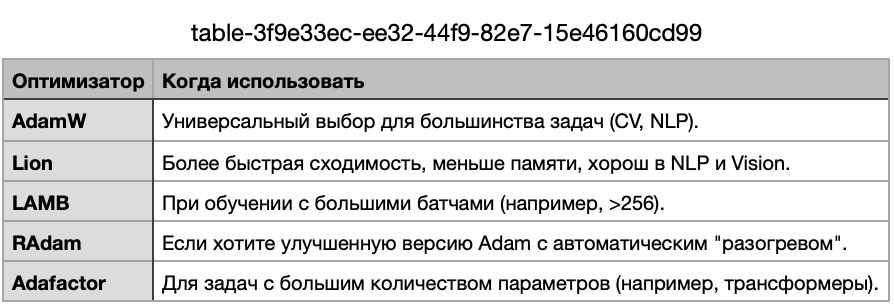
<!-- AdamW Universal choice for most tasks (CV, NLP).
Lion
Faster convergence, less memory, good for NLP and Vision.
LAMB
When training with large batches (e.g., >256).
RAdam
If you want an improved version of Adam with automatic "warmup".
Adafactor
For tasks with many parameters (e.g., transformers). -->

In [20]:
from timm import optim

In [21]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# Parameters
optimizer_name = 'lion'          # or 'lion', 'lamb', 'rmsprop', 'adafactor', 'adamp' и др.
learning_rate = 1e-4
weight_decay = 0.01

# Create Lion optimizer
optimizer = timm.optim.create_optimizer_v2(
    model,
    opt=optimizer_name,
    lr=learning_rate,
    weight_decay=weight_decay,
)

## Learning Rate Scheduler

Another useful technique is to use a [learning rate scheduler](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate). A learning rate scheduler dynamically changes the learning rate during model training.

In the simplest case, a learning rate scheduler is defined from the `torch.optim.lr_scheduler` package as a one-cycle scheduler — meaning it has only one cycle of learning rate change.

Below is an example visualization for 4 types of schedulers.

> * Note that the current learning rate value can be obtained as `optimizer.param_groups[0]["lr"]`.
> * The learning rate can also be set with `optimizer.param_groups[0]["lr"] = 0.01`
> * Always visualize the LR before starting a long training run.
> * For fine-tuning: start with an LR 10–100× smaller than during pre-training.
> * Use warmup if the batch size is large or the data is noisy.

<blockquote>
    
Note that the `ReduceLROnPlateau` scheduler can also be used, which automatically reduces the learning rate when the validation metric reaches a plateau.
    
```python

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    scheduler = ReduceLROnPlateau(optimizer, 'min')
    for epoch in range(10):
        train(...)
        val_loss = validate(...)
        # Note that step should be called after validate()
        scheduler.step(val_loss)
```

Also note that in addition to the schedule, the following code is shown below:
```python
    max_grad = 10
    for p in model.parameters():
        p.register_hook(lambda grad: torch.clamp(grad, -0.1, max_grad))
```

This technique limits the gradient value (`gradient clipping`): `lambda grad: torch.clamp(grad, -0.1, max_grad)`. It is applied to all parameters via a loop. This technique is registered as an additional function during gradient computation through what is known as a `hook`. Using the `register_hook` method, similar to a `callback`, each parameter is assigned an additional function.

</blockquote>

You can also create a schedule using the timm scheduler:

```python
scheduler, _ = timm.scheduler.create_scheduler_v2(
    optimizer,
    sched='cosine',
    num_epochs=100,
    warmup_epochs=10,
    min_lr=1e-6
)
```

<!-- Schedule (sched)	Class in timm.scheduler	Description	Main parameters
'cosine'	CosineLRScheduler	Cosine annealing with optional restarts.	num_epochs"
'step'	StepLRScheduler	Reduces lr" at a fixed step (e.g., every "decay_epochs).
'multistep'	MultiStepLRScheduler	Reduces lr at each of the specified epochs (decay_milestones).	decay_milestones"
'poly'	PolyLRScheduler	Polynomial lr decay. Works well for segmentation tasks.	power"
'tanh'	TanhLRScheduler	Hyperbolic tangent decay with optional restarts.	num_epochs"
'plateau'	PlateauLRScheduler	Reduces lr" when a metric stops improving (e.g.,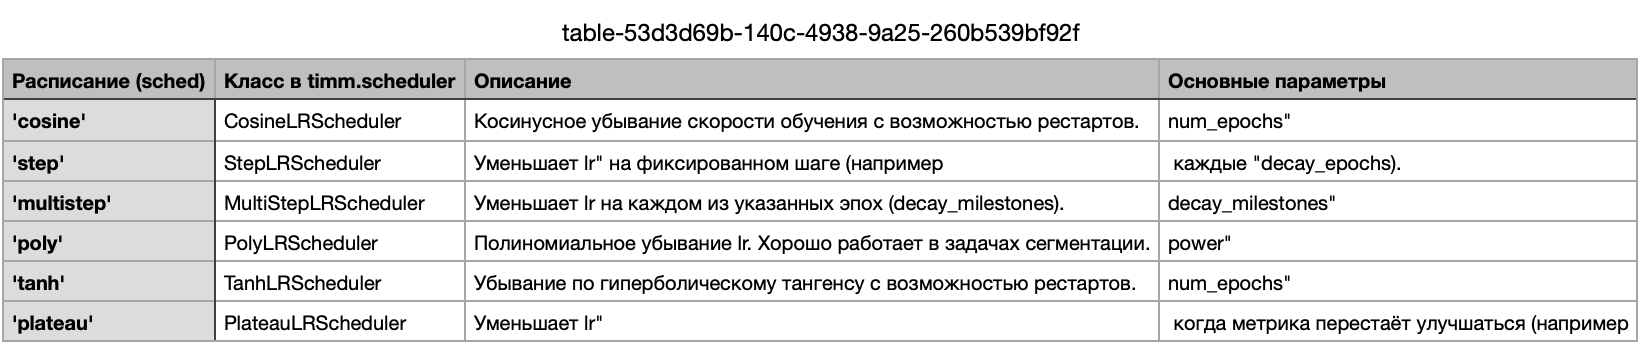 -->
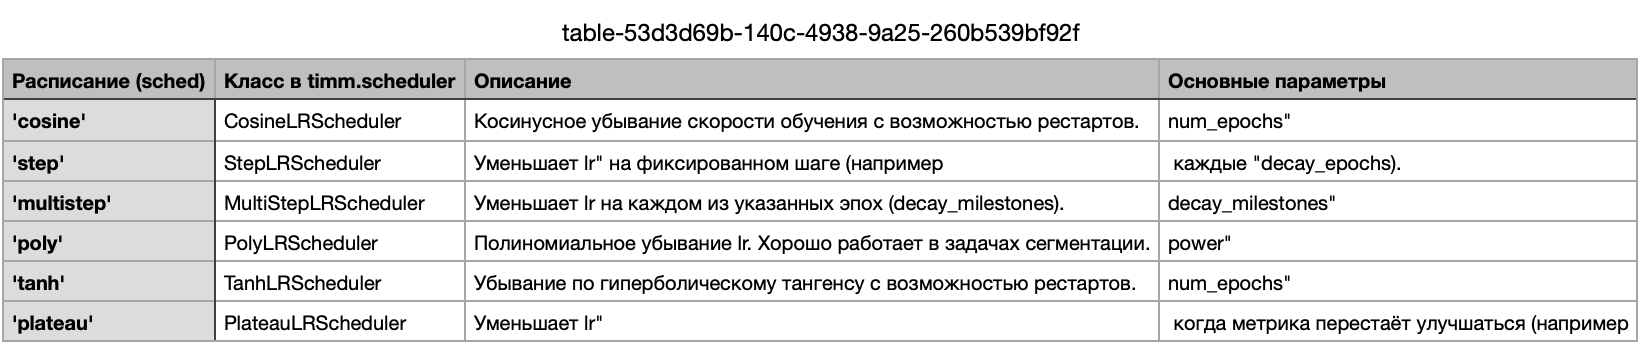

Note the following [best practices for using a varying learning rate](https://github.com/Devinterview-io/pytorch-interview-questions?tab=readme-ov-file#process-for-implementing-custom-layers):
* __Start with a fixed rate__. Begin training with a constant learning rate to establish a baseline and ensure initial convergence.
* __Tune the scheduler parameters__. The step size (`step_size`), gamma (`gamma`), and other scheduler parameters strongly affect model performance. Experiment with different settings to find the optimal configuration for your data and model.
* __Monitor loss and metrics__. Keep track of training and validation metrics. Learning rate schedulers can help fine-tune the model by adapting to its changing needs during training.

When to use learning rate scheduling:
* __Sparse data__. For data with sparse features, scheduling can help the model focus on less frequent features, thus improving performance.
* __Slow- and fast-learning features__. Not all features should be updated at the same rate. For example, in neural networks, weights in earlier layers may need more time to converge. Scheduling can help speed up their updates.
* __Loss plateaus__. When the loss function flattens out, indicating the model is learning little at the current learning rate, a scheduler can reduce the rate and help the model escape the plateau.

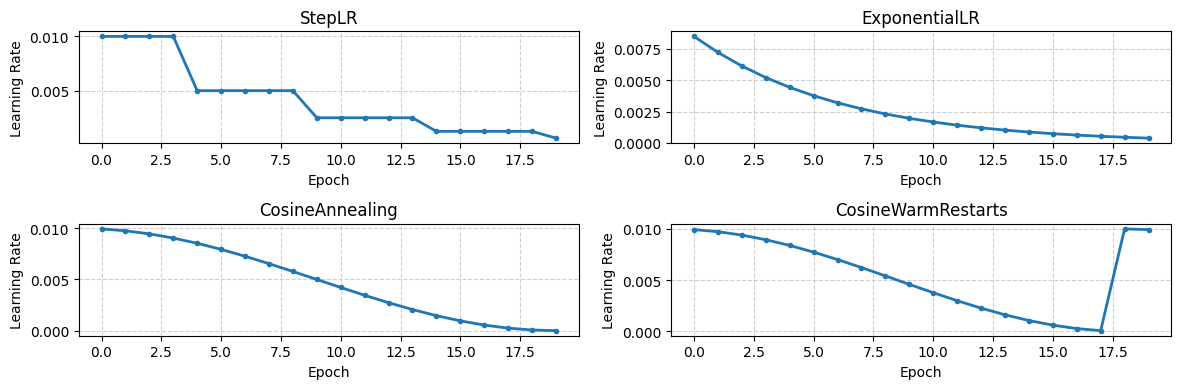

In [22]:
import matplotlib.pyplot as plt

# Hyperparameters
epochs = 20
initial_lr = 0.01

# Create a "dummy" optimizer (for LR visualization only)
dummy_model = torch.nn.Linear(1, 1)
optimizer = torch.optim.SGD(dummy_model.parameters(), lr=initial_lr)

schedulers = {
    'StepLR': torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5),
    'ExponentialLR': torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.85),
    'CosineAnnealing': torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6),
    'CosineWarmRestarts': torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=19, T_mult=1, eta_min=1e-6
    )
}

# Collect LR values per epoch
lrs = {}
for name in schedulers:
    lrs[name] = []

for name, scheduler in schedulers.items():

    for param_group in optimizer.param_groups:
        param_group['lr'] = initial_lr

    for epoch in range(epochs):
        scheduler.step()
        lrs[name].append(optimizer.param_groups[0]['lr'])
        
# Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 4))
axs = axs.ravel()

for i, (name, lr_vals) in enumerate(lrs.items()):
    axs[i].plot(range(epochs), lr_vals, marker='o', linewidth=2, markersize=3)
    axs[i].set_title(name, fontsize=12)
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Learning Rate')
    axs[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
from timm import scheduler

In [24]:
scheduler, _ = timm.scheduler.create_scheduler_v2(
    optimizer,
    sched='cosine',
    num_epochs=100,
    warmup_epochs=10,
    min_lr=1e-6
)

## Training Metrics

Training metrics are taken from the [`torchmetrics`](https://github.com/Lightning-AI/torchmetrics) library, which has an up-to-date [GitHub](https://github.com/Lightning-AI/torchmetrics) and [older documentation](https://torchmetrics.readthedocs.io/en/v0.8.2/index.html).

For metric class objects we also use so-called "function wrapping" (`wrapped_metrics`) — obtaining an instance of a class from the class defined in a dictionary.

In [25]:
from torchmetrics import *

In [26]:
metrics = {
    "acc": Accuracy(task="multiclass", num_classes=num_classes).to(device),
    "prec": Precision(task="multiclass", num_classes=num_classes, average="macro").to(device),
    "rec": Recall(task="multiclass", num_classes=num_classes, average="macro").to(device),
    "f1": F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device),
}
# Wrap for compatibility
wrapped_metrics = {k: lambda pred, target, fn=fn: fn(pred, target) for k, fn in metrics.items()}

In [27]:
wrapped_metrics

{'acc': <function __main__.<dictcomp>.<lambda>(pred, target, fn=MulticlassAccuracy())>,
 'prec': <function __main__.<dictcomp>.<lambda>(pred, target, fn=MulticlassPrecision())>,
 'rec': <function __main__.<dictcomp>.<lambda>(pred, target, fn=MulticlassRecall())>,
 'f1': <function __main__.<dictcomp>.<lambda>(pred, target, fn=MulticlassF1Score())>}

> Recall that:
>
> * `average="macro"` - average across classes,
>  * `average="micro"` - average across all samples
>  * The difference matters for `Precision, Recall, F1Score` metrics when working with imbalanced classes.

# Cross-Validation

* k-folds: 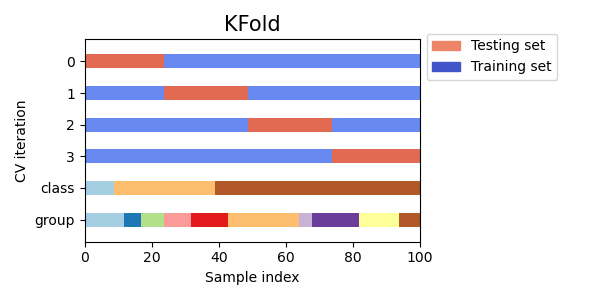
* Stratified K-fold: 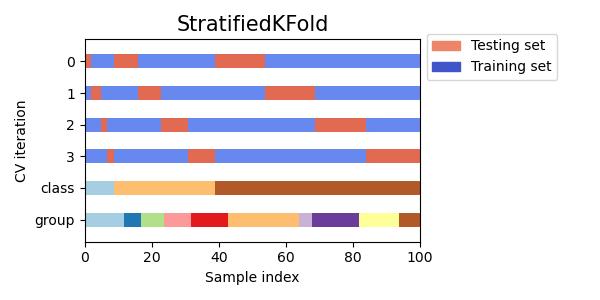
* Nested CV: 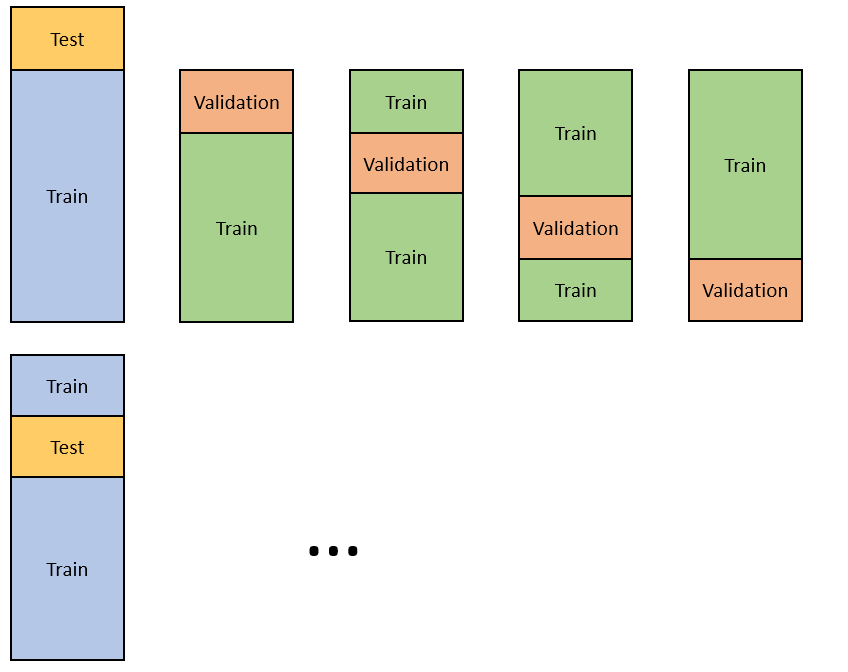

## Loss Function

<blockquote>
 
Sometimes the [`label_smoothing`](https://paperswithcode.com/method/label-smoothing) parameter is also added to the loss function, set to a small value. In this case, the final class label is formed as $$ y_s = (1-\eta y) + U[0, \eta/K] $$ where $\eta$ is a weighting coefficient, $K$ is the number of classes, and $U[0, \eta/K]$ is the uniform distribution. That is, $y_s$ is a vector where the main class has a value in the range $(0, 1)$, and the remainder of this range is "spread" across the other classes. In this case, it is expected that the implied $softmax$ activation function will not saturate, which reduces the likelihood of overfitting in the decision layer. Today `label_smoothing` is supported natively in the original loss function, as shown below.
```python 
    nn.CrossEntropyLoss(label_smoothing = ...)
```
 </blockquote>

## Model Training

### Loading the Model.

In [28]:
model = timm.create_model('mobilevitv2_050', 
                          pretrained=True, 
                          num_classes=len(traindata.classes), 
                          in_chans=3)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False 

In [29]:
# Get the head layer name via get_classifier()
classifier_name = model.get_classifier().__class__.__name__

# Find the head module (usually 'head', 'classifier', 'fc', etc.)
# timm models usually use 'head' or 'classifier'
# Check if the 'head' attribute exists
if hasattr(model, 'head'):
    head_module = model.head
elif hasattr(model, 'classifier'):
    head_module = model.classifier
else:
    # If neither is found, try to get it via get_classifier()
    # In this case we don't know the attribute name, just unfreeze the object directly
    classifier_obj = model.get_classifier()
    classifier_obj.requires_grad_(True)
    # Initialize it
    init_classifier(classifier_obj)
    head_module = None  # Already initialized

if head_module is not None:
    # Unfreeze only the head
    head_module.requires_grad_(True)
    
    # Initialize only the head
    head_module.apply(init_classifier)



In [30]:
summary(model, (1,3,224,224))

Layer (type:depth-idx)                                       Output Shape              Param #
ByobNet                                                      [1, 2]                    --
├─ConvNormAct: 1-1                                           [1, 16, 112, 112]         --
│    └─Conv2d: 2-1                                           [1, 16, 112, 112]         (432)
│    └─BatchNormAct2d: 2-2                                   [1, 16, 112, 112]         32
│    │    └─Identity: 3-1                                    [1, 16, 112, 112]         --
│    │    └─SiLU: 3-2                                        [1, 16, 112, 112]         --
├─Sequential: 1-2                                            [1, 256, 8, 8]            --
│    └─Sequential: 2-3                                       [1, 32, 112, 112]         --
│    │    └─BottleneckBlock: 3-3                             [1, 32, 112, 112]         (2,016)
│    └─Sequential: 2-4                                       [1, 64, 56, 56]           

In [31]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print('trainable p:', trainable_params, 'all p:', total_params)

trainable p: 514 all p: 1114107


In [32]:
EPOCH = 30

In [33]:
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
optimizer = timm.optim.create_optimizer_v2(
    trainable_parameters,
opt='adamw',
    lr=1e-3,
    weight_decay=0.001
)
scheduler, _ = timm.scheduler.create_scheduler_v2(
    optimizer,
    sched='cosine',
    num_epochs=EPOCH,
    warmup_epochs=2,
    min_lr=1e-4
)

Iteration 0/100, LR: 1.00e-06, Loss: 0.7581
Iteration 10/100, LR: 1.00e-01, Loss: 0.8049
Iteration 20/100, LR: 2.00e-01, Loss: 0.8042
Iteration 30/100, LR: 3.00e-01, Loss: 0.8772
Iteration 40/100, LR: 4.00e-01, Loss: 0.9097
Iteration 50/100, LR: 5.00e-01, Loss: 0.8072
Iteration 60/100, LR: 6.00e-01, Loss: 0.7770
Iteration 70/100, LR: 7.00e-01, Loss: 0.9622
Iteration 80/100, LR: 8.00e-01, Loss: 1.0145
Iteration 90/100, LR: 9.00e-01, Loss: 1.1692


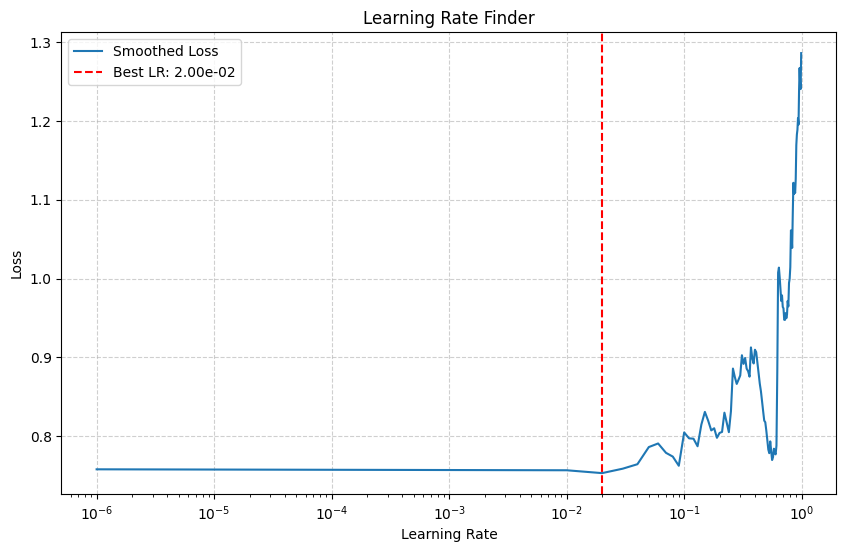

In [39]:
lr_finder(model.to(device), 
          trainloader, 
          optimizer, 
          criterion = nn.CrossEntropyLoss().to(device), 
          start_lr=1e-6,
          end_lr=1,
          num_iter=100,
          step_mode='linear', 
          smooth_f=0.015, 
          diverge_th=5, 
          device=device, 
          verbose=True, 
          plot=True);

In [40]:
# trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
# optimizer = torch.optim.AdamW(trainable_parameters, lr=9e-4, weight_decay=1e-3)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3)
criterion=torch.nn.CrossEntropyLoss().to(device)
model.to(device);


In [41]:
task = 'multiclass'

metrics = {
    'acc': Accuracy(task=task, num_classes=num_classes).to(device),
    'prec': Precision(task=task, num_classes=num_classes, average='macro').to(device),
    'rec': Recall(task=task, num_classes=num_classes, average='macro').to(device),
    'f1': F1Score(task=task, num_classes=num_classes, average='macro').to(device),
}

# torchmetrics returns tensor → wrap in lambda for compatibility
def make_metric_fn(metric_obj):
    return lambda preds, target: metric_obj(preds, target)

wrapped_metrics = {name: make_metric_fn(metric) for name, metric in metrics.items()}

### Training the Model

In [42]:

history, batch_hist = fit(
    model=model,
    train_loader=trainloader,
    val_loader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    metrics=wrapped_metrics,
    epochs=20,
    scheduler=scheduler,
    patience=7,
    min_delta=0.0001,
    device=device,
    checkpoint_path='best_model_checkpoint.pt',
    verbose=True,
    monitor_metric='acc',                  # early stopping по F1
    mode='max',
    return_batch_history = True,
)

Train:   0%|          | 0/16 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01 | Time: 3.6s | LR: 5.05e-04 | Train Loss: 1.3076 | Val Loss: 4.8840 | Val acc: 0.8181 ★


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

...

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 07 | Time: 2.5s | LR: 8.84e-04 | Train Loss: 1.9283 | Val Loss: 4.7619 | Val acc: 0.8118 


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Val:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 08 | Time: 2.5s | LR: 8.51e-04 | Train Loss: 1.5287 | Val Loss: 4.7732 | Val acc: 0.8181 
Early stopping at epoch 8. Best: 0.818056 at epoch 1


## Exercises

**1.** Investigate how different weight initialization modes affect neural network performance. For example, constant initialization `nn.init.constant_(m.weight, constant_weight)`.

__2.__  In [some cases](https://discuss.pytorch.org/t/tricks-for-being-able-to-use-a-higher-learning-rate/142179), a training strategy is recommended where an extremely low learning rate is used for several epochs to allow the model weights to settle in the right direction. These epochs will be comparatively ineffective in terms of training results, but they improve experiment stability. Then the learning rate is sharply increased and gradually decreased. It is assumed that after the initial weight settling, they can quickly train in the right direction. __You are encouraged__ to implement this strategy on your own.

> Sometimes cyclic learning rates are also used for a large number of epochs.

<code style="color : red">__3.*__</code> In a number of [papers](https://openreview.net/pdf?id=B1Yy1BxCZ), it is recommended to [increase the batch size](https://stackoverflow.com/questions/53033556/how-should-the-learning-rate-change-as-the-batch-size-change) alongside decreasing the learning rate. __You are encouraged__ to implement this training strategy on your own.

> [Sometimes](https://ar5iv.labs.arxiv.org/abs/1803.09820) it is also recommended to decrease weight decay as the training epoch grows (the `L2` regularization parameter — `weight_decay` in optimizers). If `momentum` is used, it should decrease as the learning rate increases [or cycle](https://ar5iv.labs.arxiv.org/abs/1803.09820).

<code style="color : red">__4.*__</code> Parameter configuration can be done not only by model blocks, but also by individual parameters. For example, when using `SGD with weight_decay`, it is sometimes useful to disable `weight_decay` for bias parameters. This can be done as follows.
    
```python
    bias_params = [p for name, p in self.named_parameters() if 'bias' in name]
    others = [p for name, p in self.named_parameters() if 'bias' not in name]

    optim.SGD([
                    {'params': others},
                    {'params': bias_params, 'weight_decay': 0}
                ], weight_decay=1e-2, lr=1e-2)
```
> Note that [in some cases](https://github.com/NVIDIA/DeepLearningExamples/blob/8d8b21a933fff3defb692e0527fca15532da5dc6/PyTorch/Classification/ConvNets/image_classification/training.py) `weight_decay` is not applied to batch normalization parameters.

__You are encouraged__ to test the quality of such an optimizer on your own.

<code style="color : red">__5.*__</code> Sometimes the [`label_smoothing`](https://paperswithcode.com/method/label-smoothing) parameter is also added to the loss function, set to a small value. In this case, the final class label is formed as $$ y_s = (1-\eta y) + U[0, \eta/K] $$ where $\eta$ is a weighting coefficient, $K$ is the number of classes, and $U[0, \eta/K]$ is the uniform distribution. That is, $y_s$ is a vector where the main class has a value in the range $(0, 1)$, and the remainder of this range is "spread" across the other classes. In this case, it is expected that the implied $softmax$ activation function will not saturate, which reduces the likelihood of overfitting in the decision layer. Today `label_smoothing` is supported natively in the original loss function, as shown below. __You are encouraged__ to try using this on your own.

```python 
    nn.CrossEntropyLoss(label_smoothing = ...)
```